# Notebook 1 — Estrategia de Datos y EDA
## Personalización Data-Driven en E-Commerce: Prediciendo la Recompra para Potenciar la Retención de Clientes

**Caso de uso:** ShopMart (caso ficticio) — resuelto con el dataset público **Olist Brazilian E-Commerce** (Kaggle), ~100k pedidos 2016–2018.

**Pregunta analítica guía:** ¿Cómo puede una empresa de e-commerce aprovechar los datos de su primer pedido con un cliente para anticipar si volverá a comprar, y así dirigir mejor sus esfuerzos de retención?

**Ángulo elegido (tras EDA preliminar del dataset):** El dataset Olist es una fotografía estática 2016–2018 sin etiqueta de churn explícita. Solo el **3.1%** de los clientes (`customer_unique_id`) tiene más de un pedido en todo el dataset, lo cual descarta una definición de "churn por inactividad" (no hay señal de recompra suficiente para estimar una tasa de abandono confiable por cliente con historial corto). En su lugar, se plantea el problema como:

> **Predicción de recompra binaria**: dado el comportamiento y la experiencia observados en el **primer pedido** de un cliente, ¿comprará de nuevo en la plataforma?

Este enfoque es accionable: permite a marketing/CRM decidir, inmediatamente después del primer pedido, a qué clientes dirigir campañas de reactivación o fidelización. Se complementa en el Notebook 2 con una **segmentación de clientes (RFM + clustering)** como análisis de apoyo.

**Flujo de artefactos:** Este notebook produce `train/val/test` (parquet), el pipeline de preprocesamiento (`joblib`) y un resumen del EDA (`json`) que consume el Notebook 2.


## 1. Configuración del entorno

In [8]:
# --- Bootstrap de entorno: Colab / Databricks / local (VS Code, Jupyter) ---
# No-op fuera de Colab/Databricks: detecta el entorno y solo actúa si corresponde.
import os
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
IN_DATABRICKS = "DATABRICKS_RUNTIME_VERSION" in os.environ

if IN_COLAB:
    # Colab no clona el repo (solo trae el .ipynb abierto), así que no hay requirements.txt
    # local que leer: esta lista debe mantenerse sincronizada a mano con requirements.txt.
    %pip install -q pandas numpy scikit-learn matplotlib seaborn joblib pyarrow kagglehub

    Path("dataset").mkdir(exist_ok=True, parents=True)
    Path("artifacts").mkdir(exist_ok=True, parents=True)

    # Si tienes credenciales de Kaggle, descomenta y completa estas líneas (o usa Colab
    # Secrets, ver README.colab.md): permiten que el fallback de descarga automática de
    # la sección 1 traiga el dataset sin subir los CSV a mano.
    # os.environ["KAGGLE_USERNAME"] = "tu_usuario"
    # os.environ["KAGGLE_KEY"] = "tu_token_aqui"

    print("Entorno Colab detectado y configurado (dataset/ y artifacts/ listos).")
elif IN_DATABRICKS:
    # Asume que el repo se clonó vía Databricks Repos (Repos > Add Repo): este notebook
    # vive en notebooks/ junto a dataset/, y requirements.txt está un nivel arriba.
    %pip install -q -r ../requirements.txt
    print("Entorno Databricks detectado y configurado (dependencias instaladas desde requirements.txt).")
else:
    # Local (VS Code / Jupyter): si el kernel arrancó con el cwd en la raíz del repo
    # en vez de en notebooks/ (p. ej. jupyter.notebookFileRoot mal configurado en VS Code),
    # nos reubicamos automáticamente para que las rutas relativas de este notebook funcionen.
    if not Path("dataset").exists() and Path("notebooks/dataset").exists():
        os.chdir("notebooks")
        print("Cwd ajustado automáticamente a 'notebooks/'.")
    print("Entorno local detectado. Si falta alguna librería: pip install -r requirements.txt (desde la raíz del repo).")

Entorno local detectado. Si falta alguna librería: pip install -r requirements.txt (desde la raíz del repo).


In [9]:

import warnings
warnings.filterwarnings("ignore")

import json
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (8, 4.5)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

print("Entorno configurado. RANDOM_STATE =", RANDOM_STATE)


Entorno configurado. RANDOM_STATE = 42


**Origen de los datos.** Este notebook no requiere descargar el dataset a mano desde Kaggle: si la carpeta `dataset/` ya contiene los 9 CSV de Olist (caso de una ejecución previa o de un checkout del repositorio), se usan directamente. Si no están presentes, se descargan automáticamente vía [`kagglehub`](https://github.com/Kaggle/kagglehub) — la librería oficial de Kaggle — que cachea el dataset localmente (`~/.cache/kagglehub/`) para no volver a descargarlo en ejecuciones futuras. Esto requiere una cuenta de Kaggle y un token de API (ver [kaggle.com/settings/api](https://www.kaggle.com/settings/api)) expuesto como variables de entorno `KAGGLE_USERNAME` y `KAGGLE_KEY` — localmente podés definirlas en un archivo `.env` en la raíz del repo (ver `.env.example`), que esta sección carga automáticamente; sin conexión o sin credenciales, basta con colocar los CSV manualmente en `dataset/` como respaldo.

In [10]:

if not IN_COLAB:
    try:
        from dotenv import load_dotenv
        load_dotenv()
    except ImportError:
        pass

# Rutas de trabajo
RAW_DIR = Path("dataset")
ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True, parents=True)

REQUIRED_CSVS = [
    "olist_customers_dataset.csv", "olist_orders_dataset.csv", "olist_order_items_dataset.csv",
    "olist_order_payments_dataset.csv", "olist_order_reviews_dataset.csv", "olist_products_dataset.csv",
    "olist_sellers_dataset.csv", "product_category_name_translation.csv",
]


def _has_local_dataset(folder: Path) -> bool:
    return folder.exists() and all((folder / f).exists() for f in REQUIRED_CSVS)


if _has_local_dataset(RAW_DIR):
    print(f"Dataset local encontrado en {RAW_DIR.resolve()} — no se requiere descarga.")
else:
    print("Dataset local no encontrado en 'dataset/'; se intenta descargar desde Kaggle Hub...")
    try:
        import kagglehub
    except ImportError as e:
        raise ImportError(
            "Falta la librería 'kagglehub' para descargar el dataset automáticamente. "
            "Instálala con `pip install kagglehub` y configura tus credenciales de Kaggle "
            "(https://www.kaggle.com/settings/api) como variables de entorno KAGGLE_USERNAME "
            "y KAGGLE_KEY (o en un archivo .env, ver .env.example), "
            "o coloca los 9 CSV de Olist manualmente en la carpeta 'dataset/'."
        ) from e
    cached_path = Path(kagglehub.dataset_download("olistbr/brazilian-ecommerce"))
    print(f"Dataset descargado/cacheado en: {cached_path}")
    RAW_DIR = cached_path

assert RAW_DIR.exists(), f"No se encontró la carpeta de datos: {RAW_DIR.resolve()}"
sorted(p.name for p in RAW_DIR.glob("*.csv"))


Dataset local encontrado en C:\workspace\UCG\ucg-olist-repeat-purchase-prediction\notebooks\dataset — no se requiere descarga.


['olist_customers_dataset.csv',
 'olist_geolocation_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_order_payments_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_orders_dataset.csv',
 'olist_products_dataset.csv',
 'olist_sellers_dataset.csv',
 'product_category_name_translation.csv']

## 2. Carga, perfilado e integridad

In [11]:

# Carga de las 9 tablas del dataset Olist
customers = pd.read_csv(RAW_DIR / "olist_customers_dataset.csv")
orders = pd.read_csv(
    RAW_DIR / "olist_orders_dataset.csv",
    parse_dates=[
        "order_purchase_timestamp", "order_approved_at",
        "order_delivered_carrier_date", "order_delivered_customer_date",
        "order_estimated_delivery_date",
    ],
)
items = pd.read_csv(RAW_DIR / "olist_order_items_dataset.csv", parse_dates=["shipping_limit_date"])
payments = pd.read_csv(RAW_DIR / "olist_order_payments_dataset.csv")
reviews = pd.read_csv(
    RAW_DIR / "olist_order_reviews_dataset.csv",
    parse_dates=["review_creation_date", "review_answer_timestamp"],
)
products = pd.read_csv(RAW_DIR / "olist_products_dataset.csv")
sellers = pd.read_csv(RAW_DIR / "olist_sellers_dataset.csv")
cat_translation = pd.read_csv(RAW_DIR / "product_category_name_translation.csv")

tables = {
    "customers": customers, "orders": orders, "items": items, "payments": payments,
    "reviews": reviews, "products": products, "sellers": sellers, "cat_translation": cat_translation,
}
for name, df in tables.items():
    print(f"{name:15s} shape={df.shape}")


customers       shape=(99441, 5)
orders          shape=(99441, 8)
items           shape=(112650, 7)
payments        shape=(103886, 5)
reviews         shape=(99224, 7)
products        shape=(32951, 9)
sellers         shape=(3095, 4)
cat_translation shape=(71, 2)


**Nota de alcance:** la tabla `olist_geolocation_dataset.csv` (>1M filas de pares zip↔lat/lng, con duplicados y calidad heterogénea) no se incorpora al análisis. El estado (`customer_state`) provisto en `customers` es suficiente para capturar variación geográfica sin el costo de integrar una tabla de geocodificación adicional. Se documenta como decisión de alcance.

In [12]:

def profile(df: pd.DataFrame, name: str) -> pd.DataFrame:
    prof = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "n_unique": df.nunique(),
        "pct_null": (df.isna().mean() * 100).round(2),
    })
    prof.insert(0, "table", name)
    return prof

profile_all = pd.concat([profile(df, name) for name, df in tables.items()])
profile_all[profile_all["pct_null"] > 0].sort_values("pct_null", ascending=False)


,table,dtype,n_unique,pct_null
review_comment_title,reviews,object,4527,88.34
review_comment_message,reviews,object,36159,58.70
order_delivered_customer_date,orders,datetime64[ns],95664,2.98
product_name_lenght,products,float64,66,1.85
product_category_name,products,object,73,1.85
product_description_lenght,products,float64,2960,1.85
product_photos_qty,products,float64,19,1.85
order_delivered_carrier_date,orders,datetime64[ns],81018,1.79
order_approved_at,orders,datetime64[ns],90733,0.16
product_weight_g,products,float64,2204,0.01


In [13]:

# Definición preliminar de TARGET e ID_COLS (se construyen formalmente en la sección 4,
# tras ensamblar la tabla analítica a nivel cliente/primer-pedido)
TARGET = "repeat_purchase"
ID_COLS = ["order_id", "customer_id", "customer_unique_id"]
print(f"TARGET = '{TARGET}' (se define en la sección 4)")
print(f"ID_COLS = {ID_COLS}")


TARGET = 'repeat_purchase' (se define en la sección 4)
ID_COLS = ['order_id', 'customer_id', 'customer_unique_id']


In [14]:

# Verificaciones de integridad
print("Pedidos duplicados (order_id):", orders["order_id"].duplicated().sum())
print("Clientes duplicados (customer_id):", customers["customer_id"].duplicated().sum())
print("Reseñas por pedido (order_id) - pedidos con >1 reseña:",
      (reviews.groupby("order_id").size() > 1).sum())
print("Columnas constantes en orders:", [c for c in orders.columns if orders[c].nunique() <= 1])
print("Alta cardinalidad (>50% filas únicas) en customers:",
      [c for c in customers.columns if customers[c].nunique() > 0.5 * len(customers)])
print("\nDistribución de order_status:")
print(orders["order_status"].value_counts())


Pedidos duplicados (order_id): 0
Clientes duplicados (customer_id): 0
Reseñas por pedido (order_id) - pedidos con >1 reseña: 547
Columnas constantes en orders: []
Alta cardinalidad (>50% filas únicas) en customers: ['customer_id', 'customer_unique_id']

Distribución de order_status:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [15]:

def df_hash(df: pd.DataFrame) -> str:
    # Hash determinístico de un DataFrame para trazabilidad entre ejecuciones.
    return hashlib.sha256(pd.util.hash_pandas_object(df, index=True).values.tobytes()).hexdigest()[:16]

raw_hashes = {name: df_hash(df) for name, df in tables.items()}
raw_hashes


{'customers': '2f8671c604c03daa',
 'orders': '02a3326de240fc79',
 'items': '93192dc396111431',
 'payments': '2a4d5207cbd39e84',
 'reviews': '74483b0f54ca9ed6',
 'products': '4f4539bfb481d9b5',
 'sellers': '4ea9dcc6cdab8bc0',
 'cat_translation': '3efae30a48a918de'}

## 3. Limpieza y tratamiento de datos

**Hallazgos y decisiones de limpieza:**

- `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date` tienen nulos (0.16%–2.98%): son estructurales, corresponden a pedidos no entregados (cancelados, en proceso). No se imputan — se conservan como `NaT` y se filtran más adelante cuando el análisis requiere fecha de entrega.
- `review_comment_title`/`review_comment_message` tienen >58% de nulos: es normal (comentario de texto opcional). No se usan como feature numérica; solo se usa `review_score`.
- `products` tiene ~1.85% de nulos en categoría y atributos físicos — se imputan en el pipeline de preprocesamiento (sección 5), no aquí, para evitar imputar dos veces con criterios distintos.
- **Reseñas duplicadas por pedido:** un `order_id` puede tener más de una fila en `reviews` (revisión editada). Se conserva la más reciente por `review_answer_timestamp`.
- **Reglas de negocio:** se valida que `order_delivered_customer_date >= order_purchase_timestamp` y que `price > 0`.


In [16]:

# Deduplicación de reseñas: quedarnos con la respuesta más reciente por pedido
reviews_dedup = (
    reviews.sort_values("review_answer_timestamp")
    .drop_duplicates(subset="order_id", keep="last")[["order_id", "review_score"]]
)
print(f"reviews: {reviews.shape[0]} filas -> {reviews_dedup.shape[0]} filas tras deduplicar por order_id")


reviews: 99224 filas -> 98673 filas tras deduplicar por order_id


In [17]:

# Validación de reglas de negocio
bad_dates = orders.loc[
    orders["order_delivered_customer_date"].notna()
    & (orders["order_delivered_customer_date"] < orders["order_purchase_timestamp"])
]
bad_prices = items.loc[items["price"] <= 0]
print("Pedidos con fecha de entrega anterior a la compra:", len(bad_dates))
print("Ítems con precio <= 0:", len(bad_prices))


Pedidos con fecha de entrega anterior a la compra: 0
Ítems con precio <= 0: 0


In [18]:

# Traducción de categoría de producto (pt -> en) y join con items
products_t = products.merge(cat_translation, on="product_category_name", how="left")
products_t["product_category_name_english"] = products_t["product_category_name_english"].fillna(
    products_t["product_category_name"]
)
print("Categorías sin traducción disponible:",
      products_t["product_category_name_english"].isna().sum())


Categorías sin traducción disponible: 610


## 4. Análisis exploratorio (EDA)

Para poder analizar la variable objetivo, primero se construye la **tabla analítica a nivel cliente**, tomando el **primer pedido** de cada `customer_unique_id` como unidad de observación. El target `repeat_purchase` indica si ese cliente realizó **algún pedido adicional** en cualquier momento posterior dentro del dataset.

**Supuestos declarados:**
1. **Censura por ventana de observación:** un cliente cuyo primer pedido ocurrió muy cerca del final del dataset no tuvo tiempo suficiente para recomprar. Se excluyen clientes cuyo primer pedido es posterior a `max(fecha) - 90 días`, dejando a todos los clientes elegibles al menos ~3 meses de ventana para una segunda compra.
2. **Solo primeros pedidos entregados:** se restringe a clientes cuyo primer pedido tuvo `order_status == 'delivered'`, porque las features de entrega/reseña solo están completas para pedidos entregados y porque la experiencia de entrega es, en sí misma, una señal de negocio relevante para la recompra.


In [19]:

orders_customers = orders.merge(customers, on="customer_id", how="left")

# Primer pedido por cliente único
first_idx = orders_customers.groupby("customer_unique_id")["order_purchase_timestamp"].idxmin()
first_orders = orders_customers.loc[first_idx].copy()

# Conteo total de pedidos por cliente único (en todo el dataset) -> define el target
order_counts = orders_customers.groupby("customer_unique_id")["order_id"].nunique()
first_orders["n_total_orders"] = first_orders["customer_unique_id"].map(order_counts)
first_orders[TARGET] = (first_orders["n_total_orders"] >= 2).astype(int)

print("Clientes únicos (total):", len(first_orders))
print("Tasa de recompra global (sin filtros):", first_orders[TARGET].mean().round(4))


Clientes únicos (total): 96096
Tasa de recompra global (sin filtros): 0.0312


In [20]:

max_date = orders["order_purchase_timestamp"].max()
CENSORING_CUTOFF = max_date - pd.Timedelta(days=90)
print("Fecha máxima del dataset:", max_date)
print("Cutoff de censura (90 días de margen):", CENSORING_CUTOFF)

eligible = first_orders[
    (first_orders["order_purchase_timestamp"] <= CENSORING_CUTOFF)
    & (first_orders["order_status"] == "delivered")
].copy()

print(f"\nClientes elegibles tras filtros de censura + entrega: {len(eligible)} "
      f"({len(eligible) / len(first_orders):.1%} del total)")
print("Tasa de recompra en la población elegible:", eligible[TARGET].mean().round(4))


Fecha máxima del dataset: 2018-10-17 17:30:18
Cutoff de censura (90 días de margen): 2018-07-19 17:30:18

Clientes elegibles tras filtros de censura + entrega: 84282 (87.7% del total)
Tasa de recompra en la población elegible: 0.033


In [21]:

# Agregación a nivel de pedido: ítems/productos
items_p = items.merge(products_t, on="product_id", how="left")

item_agg = items_p.groupby("order_id").agg(
    n_items=("order_item_id", "count"),
    n_sellers=("seller_id", "nunique"),
    n_categories=("product_category_name_english", "nunique"),
    total_price=("price", "sum"),
    total_freight=("freight_value", "sum"),
    avg_product_weight_g=("product_weight_g", "mean"),
    avg_product_photos_qty=("product_photos_qty", "mean"),
).reset_index()

# Categoría principal = categoría del primer ítem del pedido (evita agregaciones costosas tipo moda)
main_category = (
    items_p.sort_values(["order_id", "order_item_id"])
    .drop_duplicates("order_id", keep="first")[["order_id", "product_category_name_english"]]
    .rename(columns={"product_category_name_english": "main_category"})
)
item_agg = item_agg.merge(main_category, on="order_id", how="left")
item_agg.head(3)


,order_id,n_items,n_sellers,n_categories,total_price,total_freight,avg_product_weight_g,avg_product_photos_qty,main_category
0,00010242fe8c5a6d1ba2dd792cb16214,1,1,1,58.9,13.29,650.0,4.0,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,1,1,239.9,19.93,30000.0,2.0,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,1,1,199.0,17.87,3050.0,2.0,furniture_decor


In [22]:

# Agregación a nivel de pedido: pagos
pay_agg = payments.groupby("order_id").agg(
    total_payment_value=("payment_value", "sum"),
    max_installments=("payment_installments", "max"),
    n_payment_methods=("payment_type", "nunique"),
).reset_index()

main_payment = (
    payments.sort_values(["order_id", "payment_sequential"])
    .drop_duplicates("order_id", keep="first")[["order_id", "payment_type"]]
    .rename(columns={"payment_type": "main_payment_type"})
)
pay_agg = pay_agg.merge(main_payment, on="order_id", how="left")
pay_agg.head(3)


,order_id,total_payment_value,max_installments,n_payment_methods,main_payment_type
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,1,credit_card
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,1,credit_card
2,000229ec398224ef6ca0657da4fc703e,216.87,5,1,credit_card


In [23]:

# Ensamble de la tabla analítica final: un registro por cliente (primer pedido)
base = (
    eligible.merge(item_agg, on="order_id", how="left")
    .merge(pay_agg, on="order_id", how="left")
    .merge(reviews_dedup, on="order_id", how="left")
)

# Features de tiempo derivadas del ciclo del pedido
base["delivery_days"] = (base["order_delivered_customer_date"] - base["order_purchase_timestamp"]).dt.days
base["approval_hours"] = (base["order_approved_at"] - base["order_purchase_timestamp"]).dt.total_seconds() / 3600
base["delivery_vs_estimate_days"] = (
    base["order_estimated_delivery_date"] - base["order_delivered_customer_date"]
).dt.days
base["purchase_month"] = base["order_purchase_timestamp"].dt.month
base["purchase_dow"] = base["order_purchase_timestamp"].dt.dayofweek
base["purchase_quarter"] = base["order_purchase_timestamp"].dt.quarter

print("Tabla analítica base:", base.shape)
base.isna().mean().sort_values(ascending=False).head(8).to_frame("pct_null")


Tabla analítica base: (84282, 33)


,pct_null
main_category,0.015021
avg_product_photos_qty,0.014724
review_score,0.006870
avg_product_weight_g,0.000166
order_approved_at,0.000166
approval_hours,0.000166
delivery_vs_estimate_days,0.000095
delivery_days,0.000095


In [24]:

print(f"Hash de la tabla analítica base (trazabilidad): {df_hash(base)}")
base[[TARGET]].value_counts(normalize=True).rename("proporción")


Hash de la tabla analítica base (trazabilidad): 34946343839337bb


repeat_purchase
0                  0.966992
1                  0.033008
Name: proporción, dtype: float64

### 4.1 Variable objetivo

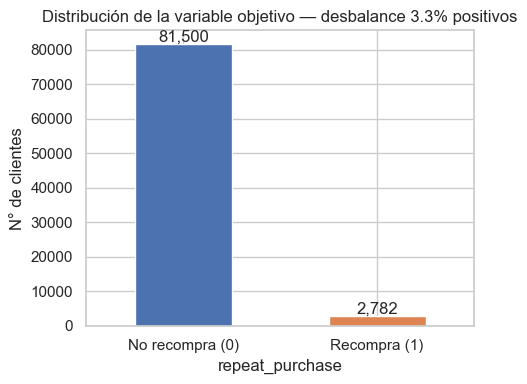

In [25]:

fig, ax = plt.subplots(figsize=(5, 4))
base[TARGET].value_counts().sort_index().plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_xticklabels(["No recompra (0)", "Recompra (1)"], rotation=0)
ax.set_ylabel("N° de clientes")
ax.set_title(f"Distribución de la variable objetivo — desbalance {base[TARGET].mean():.1%} positivos")
for i, v in enumerate(base[TARGET].value_counts().sort_index()):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()


**Hallazgo clave #1:** el desbalance de clases es severo (~3.3% de recompra). Esto condiciona toda la estrategia de modelado del Notebook 2: se usará **PR-AUC (average precision)** como métrica primaria (más informativa que accuracy o incluso ROC-AUC bajo desbalance extremo), validación estratificada, y se considerará `class_weight='balanced'` o remuestreo.

### 4.2 Análisis univariado

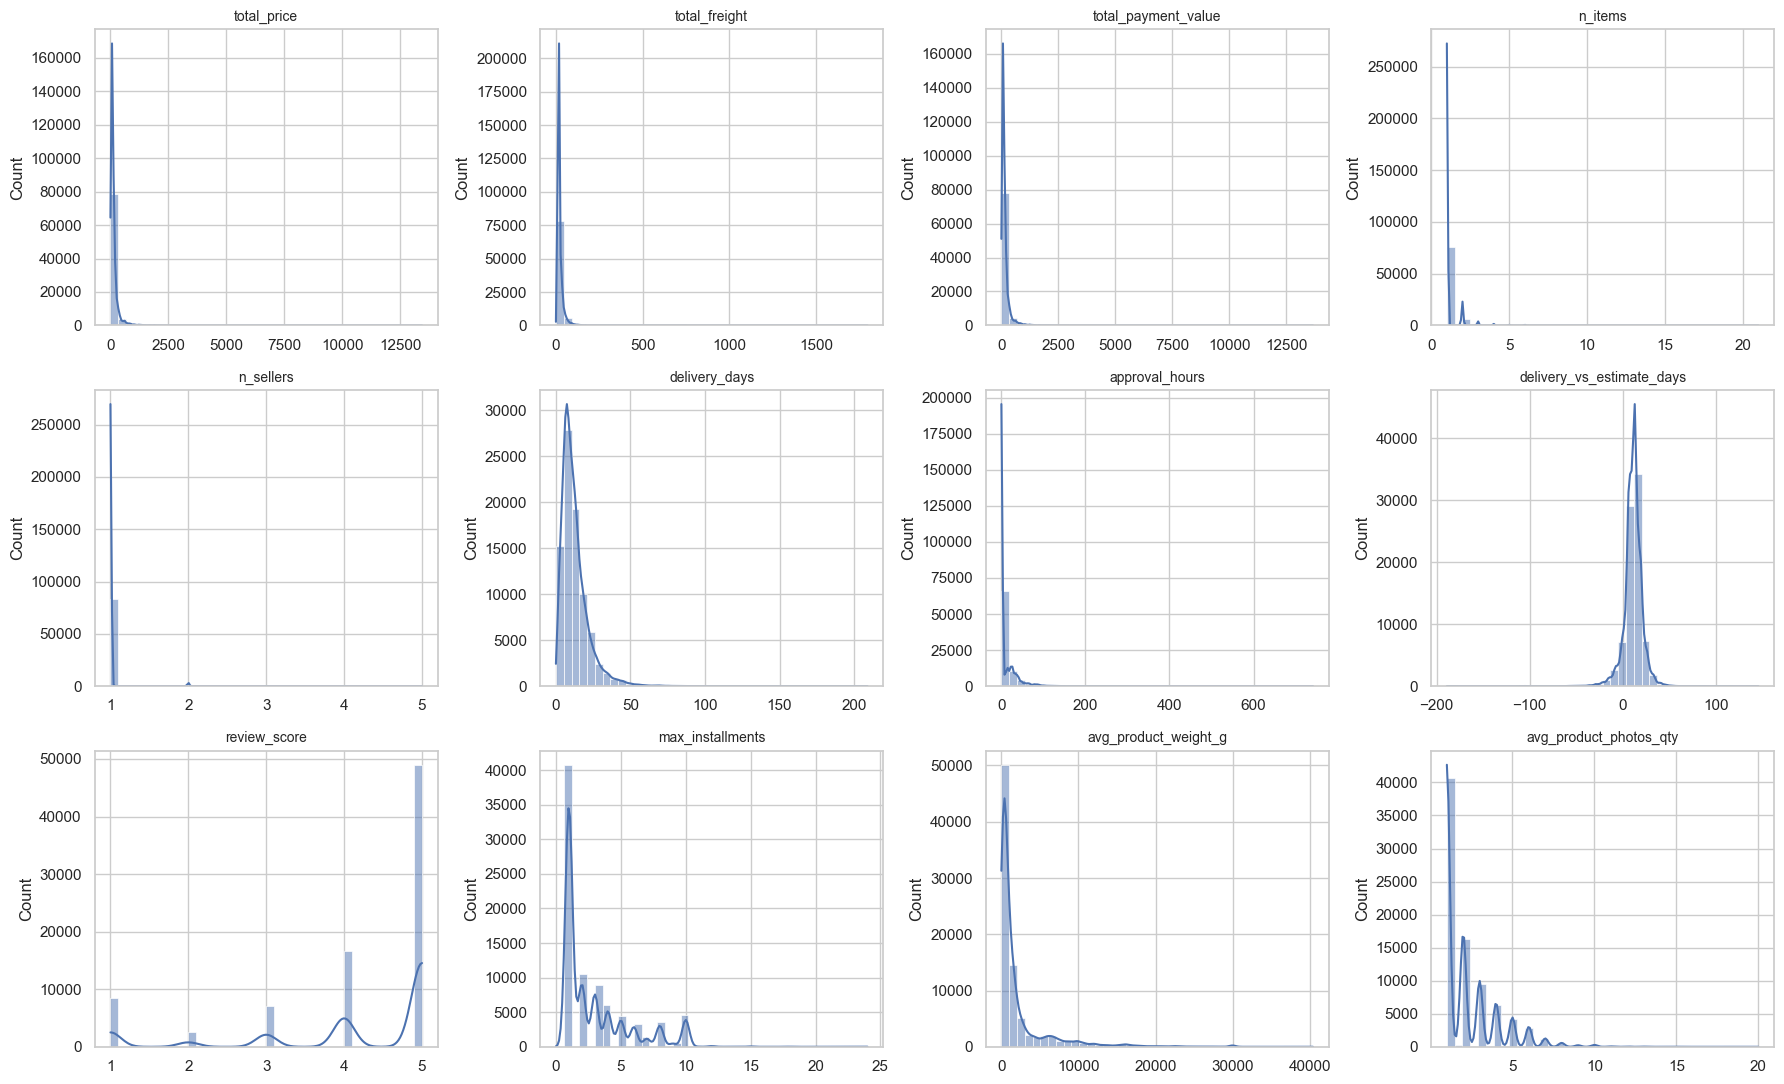

In [26]:

num_cols = [
    "total_price", "total_freight", "total_payment_value", "n_items", "n_sellers",
    "delivery_days", "approval_hours", "delivery_vs_estimate_days", "review_score",
    "max_installments", "avg_product_weight_g", "avg_product_photos_qty",
]
fig, axes = plt.subplots(3, 4, figsize=(18, 11))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(base[col].dropna(), bins=40, ax=ax, kde=True, color="#4C72B0")
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()


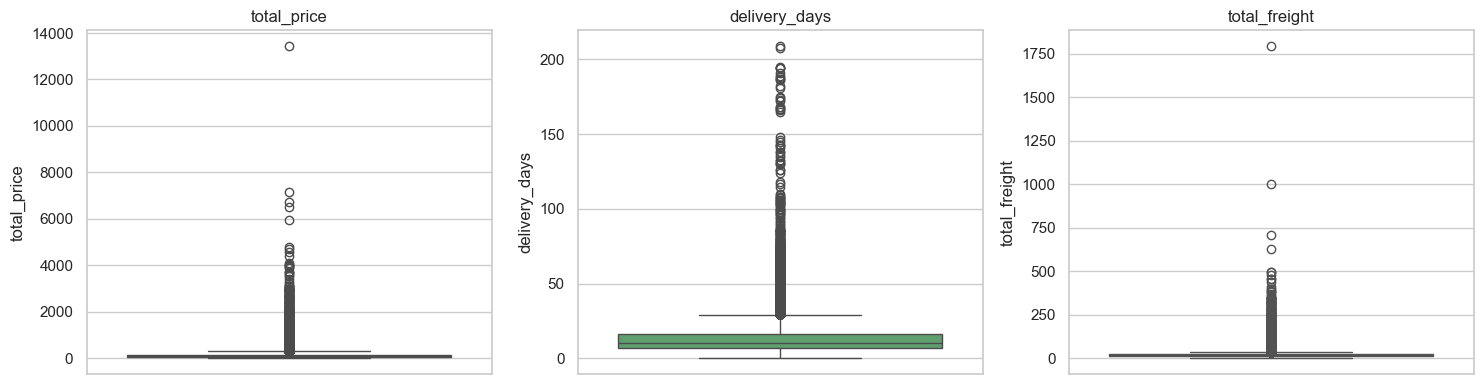

        total_price  delivery_days  total_freight
count  84282.000000   84274.000000   84282.000000
mean     137.750595      12.595201      22.659513
std      209.960774       9.833404      21.529689
min        0.850000       0.000000       0.000000
1%        11.990000       1.000000       7.390000
25%       45.900000       7.000000      13.900000
50%       87.500000      10.000000      17.050000
75%      149.900000      16.000000      23.980000
95%      399.900000      30.000000      54.190000
99%      998.000000      47.000000     103.983800
max    13440.000000     209.000000    1794.960000


In [27]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(y=base["total_price"], ax=axes[0], color="#4C72B0"); axes[0].set_title("total_price")
sns.boxplot(y=base["delivery_days"], ax=axes[1], color="#55A868"); axes[1].set_title("delivery_days")
sns.boxplot(y=base["total_freight"], ax=axes[2], color="#C44E52"); axes[2].set_title("total_freight")
plt.tight_layout()
plt.show()

print(base[["total_price", "delivery_days", "total_freight"]].describe(percentiles=[.01, .25, .5, .75, .95, .99]))


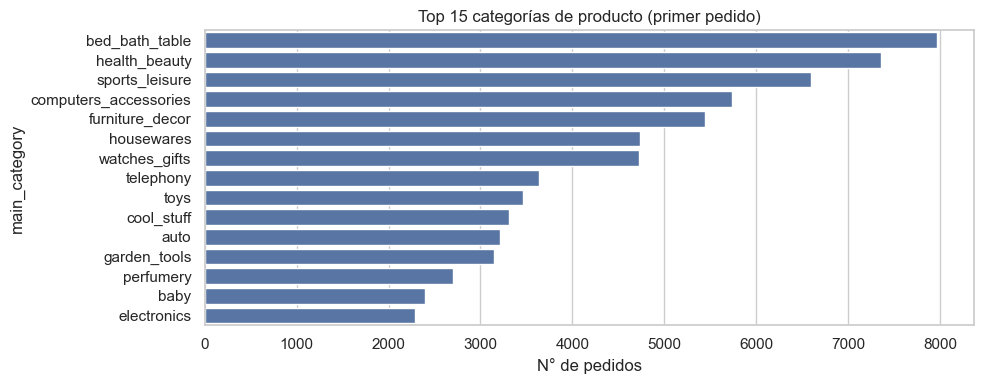


Distribución de método de pago principal:
main_payment_type
credit_card    0.771
boleto         0.201
voucher        0.015
debit_card     0.013
Name: proportion, dtype: float64


In [28]:

fig, ax = plt.subplots(figsize=(10, 4))
top_cats = base["main_category"].value_counts().head(15)
sns.barplot(x=top_cats.values, y=top_cats.index, ax=ax, color="#4C72B0")
ax.set_xlabel("N° de pedidos"); ax.set_title("Top 15 categorías de producto (primer pedido)")
plt.tight_layout()
plt.show()

print("\nDistribución de método de pago principal:")
print(base["main_payment_type"].value_counts(normalize=True).round(3))


**Hallazgo clave #2:** `total_price`, `total_freight` y `total_payment_value` presentan una **cola larga a la derecha** (típica de e-commerce: la mayoría de pedidos son de bajo/medio valor con algunos pedidos grandes). Esto sugiere evaluar transformación logarítmica o modelos robustos a escala (ensembles de árboles) en el Notebook 2. `bed_bath_table`, `health_beauty` y `sports_leisure` son las categorías más frecuentes; `boleto` (transferencia bancaria) y `credit_card` dominan el método de pago.

### 4.3 Análisis bivariado respecto al target

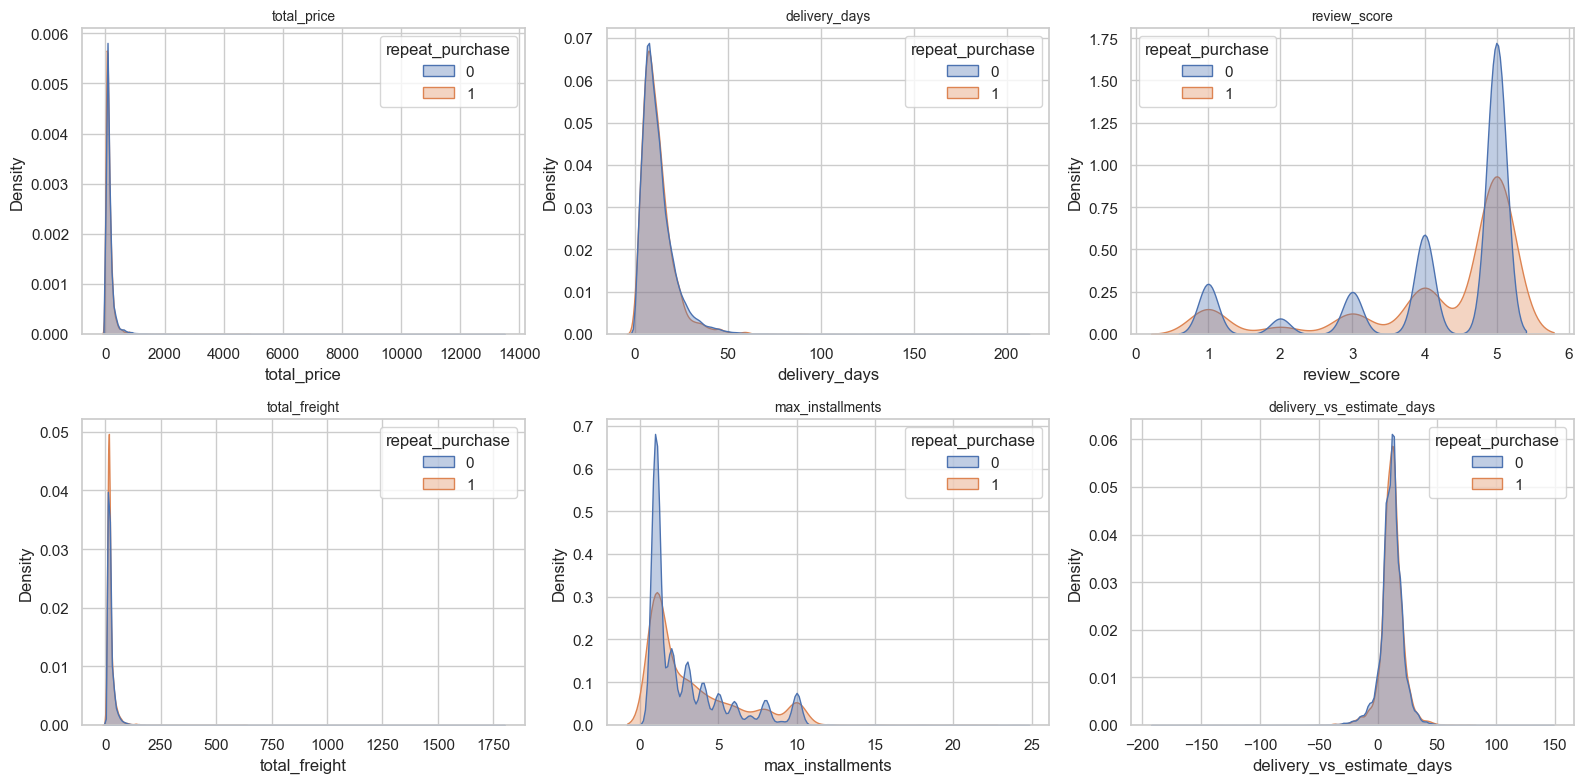

In [29]:

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
biv_cols = ["total_price", "delivery_days", "review_score", "total_freight", "max_installments", "delivery_vs_estimate_days"]
for ax, col in zip(axes.flat, biv_cols):
    sns.kdeplot(data=base, x=col, hue=TARGET, common_norm=False, ax=ax, fill=True, alpha=0.35)
    ax.set_title(col, fontsize=10)
plt.tight_layout()
plt.show()


In [30]:

print("Medianas por grupo de target:")
print(base.groupby(TARGET)[["total_price", "delivery_days", "review_score", "total_freight"]].median())

# Tasa de recompra por rango de review_score
crosstab = pd.crosstab(base["review_score"], base[TARGET], normalize="index")
print("\nTasa de recompra por review_score del primer pedido:")
print(crosstab[1].round(4))


Medianas por grupo de target:
                 total_price  delivery_days  review_score  total_freight
repeat_purchase                                                         
0                      87.96           10.0           5.0         17.060
1                      80.00           10.0           5.0         16.635

Tasa de recompra por review_score del primer pedido:
review_score
1.0    0.0318
2.0    0.0296
3.0    0.0312
4.0    0.0299
5.0    0.0346
Name: 1, dtype: float64


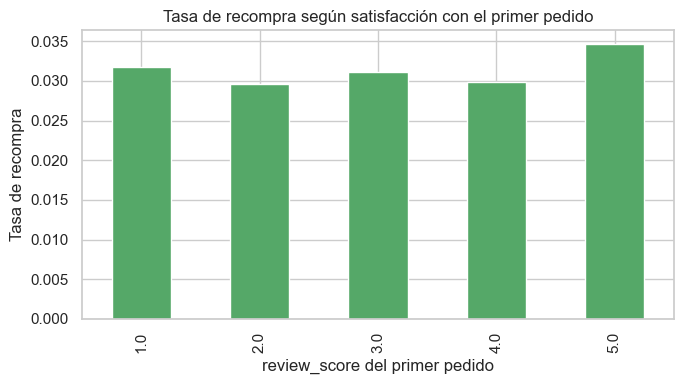

main_category
furniture_decor          0.0495
bed_bath_table           0.0478
sports_leisure           0.0418
health_beauty            0.0321
computers_accessories    0.0320
housewares               0.0308
toys                     0.0263
telephony                0.0255
watches_gifts            0.0233
cool_stuff               0.0196
Name: repeat_purchase, dtype: float64


In [31]:

fig, ax = plt.subplots(figsize=(7, 4))
rate_by_review = base.groupby("review_score")[TARGET].mean()
rate_by_review.plot(kind="bar", ax=ax, color="#55A868")
ax.set_ylabel("Tasa de recompra"); ax.set_xlabel("review_score del primer pedido")
ax.set_title("Tasa de recompra según satisfacción con el primer pedido")
plt.tight_layout()
plt.show()

# Tasa de recompra por top-10 categorías (con suficiente volumen)
top10 = base["main_category"].value_counts().head(10).index
rate_by_cat = base[base["main_category"].isin(top10)].groupby("main_category")[TARGET].mean().sort_values(ascending=False)
print(rate_by_cat.round(4))


**Hallazgo clave #3:** contrario a lo esperado por la literatura de customer experience, la tasa de recompra **no varía de forma monótona con `review_score`** (oscila entre 2.96% y 3.46% entre 1 y 5 estrellas, sin una tendencia clara — ver medianas y crosstab arriba). La satisfacción declarada en la reseña del primer pedido, por sí sola, **no es un driver fuerte de recompra** en este dataset. Sí se observan diferencias algo mayores en la tasa de recompra entre categorías de producto y en variables de tamaño/complejidad del pedido (`n_items`, `max_installments`), aunque también de magnitud modesta — ver sección 4.4.

### 4.4 Correlaciones y colinealidad

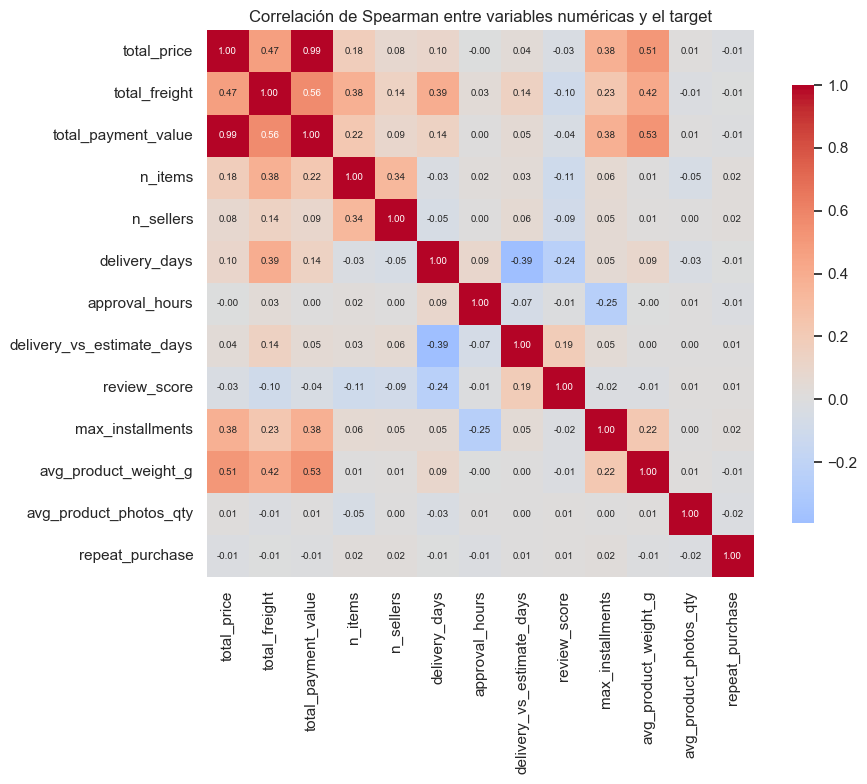

In [32]:

corr_cols = num_cols + [TARGET]
corr = base[corr_cols].corr(method="spearman")
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f", ax=ax, square=True,
            cbar_kws={"shrink": .8}, annot_kws={"size": 7})
ax.set_title("Correlación de Spearman entre variables numéricas y el target")
plt.tight_layout()
plt.show()


In [33]:

print("Correlación (Spearman) de cada variable numérica con el target, ordenada:")
print(corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False))


Correlación (Spearman) de cada variable numérica con el target, ordenada:
n_items                      0.024480
max_installments             0.022314
avg_product_photos_qty      -0.022119
n_sellers                    0.017396
approval_hours              -0.014681
total_price                 -0.012425
total_payment_value         -0.011451
review_score                 0.009986
delivery_vs_estimate_days    0.008587
avg_product_weight_g        -0.007936
delivery_days               -0.006287
total_freight               -0.006094
Name: repeat_purchase, dtype: float64


**Hallazgo clave #4:** `total_price` y `total_payment_value` están altamente correlacionadas entre sí (ambas miden el valor del pedido) — se conservará solo una en el modelado para evitar colinealidad redundante. Ninguna variable individual tiene correlación fuerte con el target (todas por debajo de ~0.1 en valor absoluto), lo que es esperable: la recompra es un fenómeno multi-causal que requiere un modelo capaz de capturar interacciones, no una sola variable dominante.

### 4.5 Análisis temporal

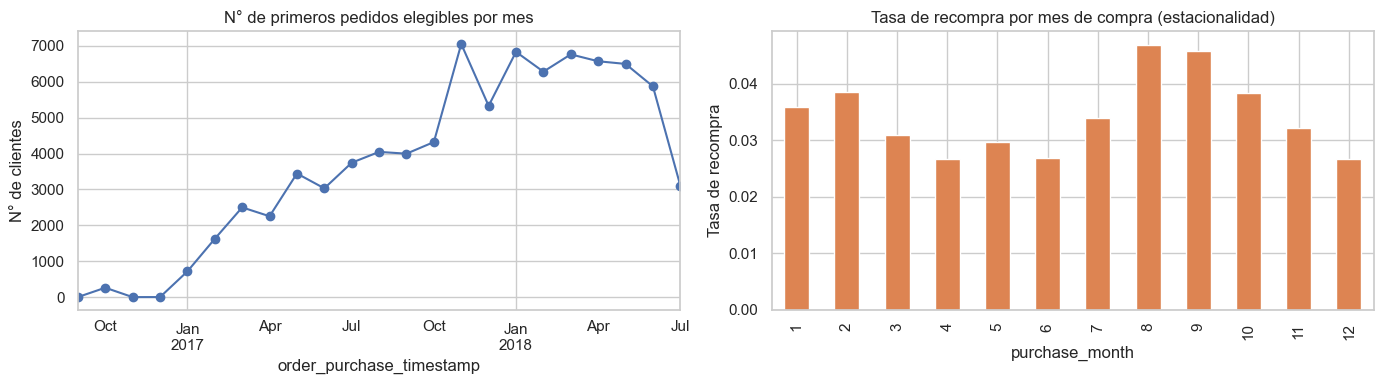

In [34]:

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

monthly = base.set_index("order_purchase_timestamp").resample("MS").size()
monthly.plot(ax=axes[0], marker="o", color="#4C72B0")
axes[0].set_title("N° de primeros pedidos elegibles por mes")
axes[0].set_ylabel("N° de clientes")

rate_by_month = base.groupby("purchase_month")[TARGET].mean()
rate_by_month.plot(kind="bar", ax=axes[1], color="#DD8452")
axes[1].set_title("Tasa de recompra por mes de compra (estacionalidad)")
axes[1].set_ylabel("Tasa de recompra")

plt.tight_layout()
plt.show()


**Hallazgo clave #5:** el volumen de pedidos crece sostenidamente durante 2017 (crecimiento de la plataforma Olist), lo cual es coherente con el contexto de negocio. La tasa de recompra muestra variación estacional leve; se incluye `purchase_month`/`purchase_quarter` como features para que el modelo pueda capturar estacionalidad si es relevante.

### 4.6 Síntesis del EDA — hallazgos clave

1. **Desbalance severo del target** (~3.3% recompra): condiciona métrica de evaluación (PR-AUC) y estrategia de validación en NB2.
2. **Colas largas en variables monetarias** (`total_price`, `total_freight`): candidatas a modelos robustos a escala (ensembles) o transformación log.
3. **Ninguna variable individual (incluyendo `review_score`) es un driver fuerte de la recompra por sí sola**: las correlaciones son todas débiles (|ρ| < 0.03); el fenómeno parece multi-causal, reforzando la necesidad de un modelo que combine muchas señales débiles en vez de depender de una regla simple.
4. **Colinealidad entre `total_price` y `total_payment_value`**: se retiene una sola en el pipeline.
5. **Estacionalidad moderada** en volumen y tasa de recompra: se incorpora mes/trimestre de compra como feature.
6. **71 categorías de producto con distribución long-tail**: se agruparán categorías poco frecuentes en `"other"` para controlar cardinalidad (sección 5).
7. **customer_city tiene ~4,000 valores únicos** (alta cardinalidad, ruido potencial): se excluye del modelado, reteniendo `customer_state` (27 categorías) como proxy geográfico.


## 5. Ingeniería de características y preprocesamiento

In [35]:

# Agrupar categorías de producto poco frecuentes en "other" (controla cardinalidad y evita
# niveles con muy pocas observaciones en el one-hot encoding)
TOP_N_CATEGORIES = 15
top_categories = base["main_category"].value_counts().head(TOP_N_CATEGORIES).index
base["main_category_grouped"] = np.where(
    base["main_category"].isin(top_categories), base["main_category"], "other"
)
print(base["main_category_grouped"].value_counts())


main_category_grouped
other                    17552
bed_bath_table            7972
health_beauty             7357
sports_leisure            6595
computers_accessories     5742
furniture_decor           5438
housewares                4741
watches_gifts             4727
telephony                 3642
toys                      3465
cool_stuff                3308
auto                      3214
garden_tools              3146
perfumery                 2699
baby                      2398
electronics               2286
Name: count, dtype: int64


In [36]:

# Variables derivadas adicionales con justificación de dominio
base["freight_ratio"] = base["total_freight"] / base["total_price"].replace(0, np.nan)  # peso relativo del flete
base["is_late_delivery"] = (base["delivery_vs_estimate_days"] < 0).astype("Int64")       # entrega tardía vs. estimado
base["has_review"] = base["review_score"].notna().astype(int)                             # dejó reseña o no
base["price_per_item"] = base["total_price"] / base["n_items"].replace(0, np.nan)

print(base[["freight_ratio", "is_late_delivery", "has_review", "price_per_item"]].describe())


       freight_ratio  is_late_delivery   has_review  price_per_item
count   84282.000000           84282.0  84282.00000    84282.000000
mean        0.307163          0.080646      0.99313      125.951189
std         0.313442          0.272292      0.08260      189.266183
min         0.000000               0.0      0.00000        0.850000
25%         0.131266               0.0      1.00000       42.000000
50%         0.223683               0.0      1.00000       79.000000
75%         0.378446               0.0      1.00000      139.900000
max        21.447059               1.0      1.00000     6735.000000


In [37]:

# Diagnóstico preliminar de relevancia: mutual information entre features numéricas y el target
from sklearn.feature_selection import mutual_info_classif

mi_num_cols = [
    "total_price", "total_freight", "n_items", "n_sellers", "delivery_days", "approval_hours",
    "delivery_vs_estimate_days", "review_score", "max_installments", "freight_ratio",
    "is_late_delivery", "has_review", "price_per_item", "purchase_month",
]
mi_df = base[mi_num_cols].fillna(base[mi_num_cols].median())
mi_scores = mutual_info_classif(mi_df, base[TARGET], random_state=RANDOM_STATE)
mi_result = pd.Series(mi_scores, index=mi_num_cols).sort_values(ascending=False)
print(mi_result.round(4))


n_sellers                    0.0230
has_review                   0.0157
n_items                      0.0107
review_score                 0.0060
max_installments             0.0026
purchase_month               0.0021
total_price                  0.0015
price_per_item               0.0015
freight_ratio                0.0012
total_freight                0.0010
approval_hours               0.0000
delivery_days                0.0000
delivery_vs_estimate_days    0.0000
is_late_delivery             0.0000
dtype: float64


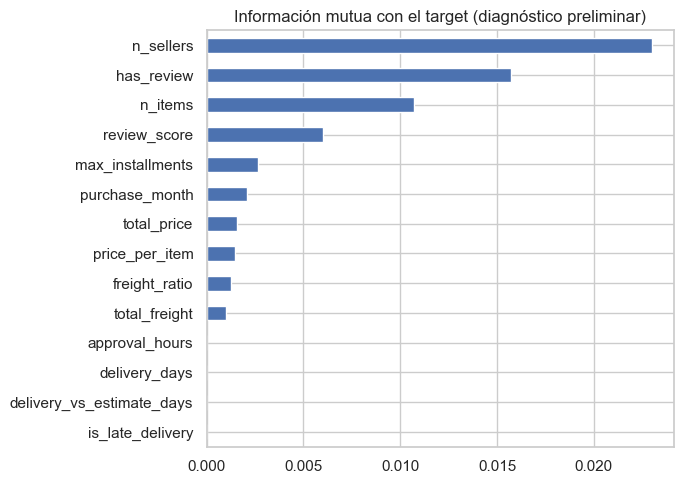

In [38]:

fig, ax = plt.subplots(figsize=(7, 5))
mi_result.plot(kind="barh", ax=ax, color="#4C72B0")
ax.invert_yaxis()
ax.set_title("Información mutua con el target (diagnóstico preliminar)")
plt.tight_layout()
plt.show()


**Selección final de features.** Se excluyen identificadores (`order_id`, `customer_id`, `customer_unique_id`), columnas usadas solo para construir el target o filtros (`order_status`, `n_total_orders`), timestamps crudos (ya se derivaron features de ellos), `customer_city` (alta cardinalidad) y `total_payment_value`/`main_category` (redundantes con `total_price`/`main_category_grouped`, ver colinealidad sección 4.4).

In [39]:

NUMERIC_FEATURES = [
    "n_items", "n_sellers", "n_categories", "total_price", "total_freight",
    "avg_product_weight_g", "avg_product_photos_qty", "max_installments",
    "n_payment_methods", "delivery_days", "approval_hours", "delivery_vs_estimate_days",
    "review_score", "purchase_month", "purchase_dow", "purchase_quarter",
    "freight_ratio", "price_per_item",
]
CATEGORICAL_FEATURES = ["main_category_grouped", "main_payment_type", "customer_state", "is_late_delivery", "has_review"]
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

model_df = base[["customer_unique_id", "order_id"] + FEATURES + [TARGET]].copy()
print("Dimensiones de la tabla de modelado:", model_df.shape)
model_df.head(3)


Dimensiones de la tabla de modelado: (84282, 26)


,customer_unique_id,order_id,n_items,n_sellers,n_categories,total_price,total_freight,avg_product_weight_g,avg_product_photos_qty,max_installments,n_payment_methods,delivery_days,approval_hours,delivery_vs_estimate_days,review_score,purchase_month,purchase_dow,purchase_quarter,freight_ratio,price_per_item,main_category_grouped,main_payment_type,customer_state,is_late_delivery,has_review,repeat_purchase
0,0000366f3b9a7992bf8c76cfdf3221e2,e22acc9c116caa3f2b7121bbb380d08e,1,1,1,129.9,12.00,1500.0,1.0,8.0,1.0,6.0,0.247500,4.0,5.0,5,3,2,0.092379,129.9,bed_bath_table,credit_card,SP,0,1,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,3594e05a005ac4d06a72673270ef9ec9,1,1,1,18.9,8.29,375.0,1.0,1.0,1.0,3.0,7.238056,4.0,4.0,5,0,2,0.438624,18.9,health_beauty,credit_card,SP,0,1,0
2,0000f46a3911fa3c0805444483337064,b33ec3b699337181488304f362a6b734,1,1,1,69.0,17.22,1500.0,3.0,8.0,1.0,25.0,0.000000,1.0,3.0,3,4,1,0.249565,69.0,other,credit_card,SC,0,1,0


In [40]:

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), NUMERIC_FEATURES),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), CATEGORICAL_FEATURES),
    ],
    remainder="drop",
)
preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

## 6. Particiones y persistencia de artefactos

**Esquema de partición:** hold-out estratificado 70/15/15 (train/val/test) sobre `repeat_purchase`, dado que el dataset no requiere un split temporal estricto adicional (la censura por ventana de 90 días ya elimina el sesgo de "tiempo insuficiente para recomprar"; sin embargo, para reforzar la validez temporal se ordena por `order_purchase_timestamp` antes del split para que el conjunto de test contenga, en su mayoría, a los clientes más recientes). Se usa estratificación por ser un problema con desbalance severo de clases.

In [41]:

model_df = model_df.sort_values("order_purchase_timestamp" if "order_purchase_timestamp" in model_df.columns else FEATURES[0])
# (la columna de timestamp no forma parte de FEATURES; se reincorpora aquí solo para ordenar)
model_df = base[["customer_unique_id", "order_id", "order_purchase_timestamp"] + FEATURES + [TARGET]].copy()
model_df = model_df.sort_values("order_purchase_timestamp").reset_index(drop=True)

X = model_df[FEATURES]
y = model_df[TARGET]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

for name, split_y in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"{name:5s} n={len(split_y):6d}  tasa_recompra={split_y.mean():.4f}")


train n= 58997  tasa_recompra=0.0330
val   n= 12642  tasa_recompra=0.0330
test  n= 12643  tasa_recompra=0.0331


In [42]:

# Ajustar el preprocesador SOLO sobre train (evita fuga de información)
preprocessor.fit(X_train)

feature_names = preprocessor.get_feature_names_out().tolist()
print(f"N° de features tras preprocesamiento: {len(feature_names)}")

def transform_to_df(X_split):
    arr = preprocessor.transform(X_split)
    return pd.DataFrame(arr, columns=feature_names, index=X_split.index)

X_train_t = transform_to_df(X_train)
X_val_t = transform_to_df(X_val)
X_test_t = transform_to_df(X_test)
X_train_t.shape, X_val_t.shape, X_test_t.shape


N° de features tras preprocesamiento: 70


((58997, 70), (12642, 70), (12643, 70))

In [43]:

# Persistencia de artefactos para el Notebook 2
X_train_t.to_parquet(ARTIFACTS_DIR / "X_train.parquet")
X_val_t.to_parquet(ARTIFACTS_DIR / "X_val.parquet")
X_test_t.to_parquet(ARTIFACTS_DIR / "X_test.parquet")

y_train.to_frame(TARGET).to_parquet(ARTIFACTS_DIR / "y_train.parquet")
y_val.to_frame(TARGET).to_parquet(ARTIFACTS_DIR / "y_val.parquet")
y_test.to_frame(TARGET).to_parquet(ARTIFACTS_DIR / "y_test.parquet")

# Tablas crudas (pre-transformación) con IDs, útiles para trazabilidad, interpretabilidad y
# para la segmentación RFM complementaria del Notebook 2
model_df.loc[X_train.index].to_parquet(ARTIFACTS_DIR / "raw_train.parquet")
model_df.loc[X_val.index].to_parquet(ARTIFACTS_DIR / "raw_val.parquet")
model_df.loc[X_test.index].to_parquet(ARTIFACTS_DIR / "raw_test.parquet")

# Historial completo de pedidos por cliente (para RFM/segmentación en NB2)
orders_customers[["customer_unique_id", "order_id", "order_purchase_timestamp", "order_status"]].merge(
    item_agg[["order_id", "total_price"]], on="order_id", how="left"
).to_parquet(ARTIFACTS_DIR / "orders_history.parquet")

joblib.dump(preprocessor, ARTIFACTS_DIR / "preprocessor.joblib")

print("Artefactos guardados en:", ARTIFACTS_DIR.resolve())
sorted(p.name for p in ARTIFACTS_DIR.glob("*"))


Artefactos guardados en: C:\workspace\UCG\ucg-olist-repeat-purchase-prediction\notebooks\artifacts


['X_test.parquet',
 'X_train.parquet',
 'X_val.parquet',
 'customer_segments.parquet',
 'eda_summary.json',
 'model_card.json',
 'orders_history.parquet',
 'preprocessor.joblib',
 'raw_test.parquet',
 'raw_train.parquet',
 'raw_val.parquet',
 'repeat_purchase_model.joblib',
 'test_predictions.parquet',
 'y_test.parquet',
 'y_train.parquet',
 'y_val.parquet']

In [44]:

eda_summary = {
    "target": TARGET,
    "target_definition": "1 si el customer_unique_id tiene >=2 pedidos en el dataset completo; "
                          "features derivadas exclusivamente del PRIMER pedido (evita fuga de información temporal).",
    "censoring_cutoff": str(CENSORING_CUTOFF),
    "n_customers_total": int(len(first_orders)),
    "n_customers_eligible": int(len(eligible)),
    "class_balance": {"negative": float((1 - base[TARGET]).mean()), "positive": float(base[TARGET].mean())},
    "n_features": len(FEATURES),
    "numeric_features": NUMERIC_FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "feature_names_transformed": feature_names,
    "splits": {
        "train": {"n": int(len(y_train)), "rate": float(y_train.mean())},
        "val": {"n": int(len(y_val)), "rate": float(y_val.mean())},
        "test": {"n": int(len(y_test)), "rate": float(y_test.mean())},
    },
    "key_findings": [
        "Desbalance severo del target (~3.3% recompra) -> métrica primaria PR-AUC en NB2.",
        "Colas largas en variables monetarias (total_price, total_freight).",
        "Ninguna variable individual (incl. review_score) es un driver fuerte de la recompra; correlaciones todas debiles (|rho|<0.03).",
        "Colinealidad entre total_price y total_payment_value: se retiene solo total_price.",
        "Estacionalidad moderada en volumen y tasa de recompra por mes.",
        "71 categorías de producto con long-tail: agrupadas a top 15 + 'other'.",
        "customer_city (alta cardinalidad) excluido; se retiene customer_state.",
    ],
    "raw_table_hashes": raw_hashes,
    "base_table_hash": df_hash(base),
    "random_state": RANDOM_STATE,
}

with open(ARTIFACTS_DIR / "eda_summary.json", "w", encoding="utf-8") as f:
    json.dump(eda_summary, f, indent=2, ensure_ascii=False)

print(json.dumps(eda_summary, indent=2, ensure_ascii=False)[:1500], "...")


{
  "target": "repeat_purchase",
  "target_definition": "1 si el customer_unique_id tiene >=2 pedidos en el dataset completo; features derivadas exclusivamente del PRIMER pedido (evita fuga de información temporal).",
  "censoring_cutoff": "2018-07-19 17:30:18",
  "n_customers_total": 96096,
  "n_customers_eligible": 84282,
  "class_balance": {
    "negative": 0.9669917657388292,
    "positive": 0.03300823426117083
  },
  "n_features": 23,
  "numeric_features": [
    "n_items",
    "n_sellers",
    "n_categories",
    "total_price",
    "total_freight",
    "avg_product_weight_g",
    "avg_product_photos_qty",
    "max_installments",
    "n_payment_methods",
    "delivery_days",
    "approval_hours",
    "delivery_vs_estimate_days",
    "review_score",
    "purchase_month",
    "purchase_dow",
    "purchase_quarter",
    "freight_ratio",
    "price_per_item"
  ],
  "categorical_features": [
    "main_category_grouped",
    "main_payment_type",
    "customer_state",
    "is_late_deliver

## Conclusión del Notebook 1

Se construyó una tabla analítica a nivel cliente (primer pedido), con un target de recompra binaria definido de forma no filtrada (sin fuga de información: las features provienen exclusivamente de la experiencia del primer pedido, y el target usa información de pedidos *posteriores*, disponible solo en el momento de entrenar, no en producción real — en despliegue, el modelo se ejecutaría con las features del primer pedido apenas esté disponible, y la etiqueta real se conocería después de la ventana de observación).

El EDA reveló un desbalance de clases severo y la ausencia de un driver individual fuerte de la recompra (todas las correlaciones univariadas son débiles, incluida la de `review_score`), lo que orienta el modelado del Notebook 2 hacia un modelo capaz de combinar múltiples señales débiles en vez de depender de una regla simple. Se aplicaron decisiones de tratamiento de cardinalidad y colinealidad en el pipeline de preprocesamiento. Los artefactos (`train/val/test` transformados y crudos, `preprocessor.joblib`, `eda_summary.json`, historial de pedidos) quedan listos para el **Notebook 2 — Modelado y Validación**.
